In [11]:
#Anna Wojciechowska, Oslo, October 2026
#data source:
#https://archive.ics.uci.edu/dataset/291/airfoil+self+noise
from ucimlrepo import fetch_ucirepo

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [12]:
airfoil = fetch_ucirepo(id=291)
X = airfoil.data.features
y = airfoil.data.targets
df = X.join(y)

In [13]:
#since chord -lengt values are in 6 groups corresponding to different airwings models, 
#this value will be used as categorical
print(df["chord-length"].unique()) 
df["chord"] = df["chord-length"].astype("category")

[0.3048 0.2286 0.1524 0.0508 0.0254 0.1016]


In [29]:
df.shape

(1503, 7)

In [14]:
#categorical values requires special treatement - dummy encoding
dummies = pd.get_dummies(df["chord"], prefix="dummy_chord_category", drop_first=True, dtype=float)
df = df.join(dummies)
#tutaj do i need it
DUMMY = list(dummies.columns)
df.head()

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,scaled-sound-pressure,chord,dummy_chord_category_0.0508,dummy_chord_category_0.1016,dummy_chord_category_0.1524,dummy_chord_category_0.2286,dummy_chord_category_0.3048
0,800,0.0,0.3048,71.3,0.002663,126.201,0.3048,0.0,0.0,0.0,0.0,1.0
1,1000,0.0,0.3048,71.3,0.002663,125.201,0.3048,0.0,0.0,0.0,0.0,1.0
2,1250,0.0,0.3048,71.3,0.002663,125.951,0.3048,0.0,0.0,0.0,0.0,1.0
3,1600,0.0,0.3048,71.3,0.002663,127.591,0.3048,0.0,0.0,0.0,0.0,1.0
4,2000,0.0,0.3048,71.3,0.002663,127.461,0.3048,0.0,0.0,0.0,0.0,1.0


In [25]:
df.shape

(1503, 13)

In [6]:
# split data using small subsample
df, _ = train_test_split(df, train_size=30, random_state=13, stratify=df["chord"])
df = df.reset_index(drop=True)
print(df.shape)
#split data
train_idx, test_idx = train_test_split(
    df.index, test_size=1/3, random_state=13, stratify=df["chord"]
)
df["train"] = df.index.isin(train_idx)
pd.crosstab(df["chord"], df["train"], normalize="columns").round(2)

(30, 12)


train,False,True
chord,,
0.0254,0.2,0.20
0.0508,0.2,0.15
0.1016,0.1,0.20
0.1524,0.2,0.15
0.2286,0.2,0.15
0.3048,0.1,0.15


In [7]:
df.shape

(30, 13)

In [11]:
df.columns

Index(['frequency', 'attack-angle', 'chord-length', 'free-stream-velocity',
       'suction-side-displacement-thickness', 'scaled-sound-pressure', 'chord',
       'dummy_chord_category_0.0508', 'dummy_chord_category_0.1016',
       'dummy_chord_category_0.1524', 'dummy_chord_category_0.2286',
       'dummy_chord_category_0.3048', 'train'],
      dtype='str')

In [5]:
#making frequency log
df["frequency"] = np.log(df["frequency"])

In [15]:
NUM = ["frequency", "attack-angle", "free-stream-velocity",
       "suction-side-displacement-thickness"]
DUMMY = [c for c in df.columns if c.startswith("dummy_")]
PRED = NUM + DUMMY 
OUT = "scaled-sound-pressure"

In [31]:

#for lmbda in lambda_seq:
#    print(lmbda)

In [32]:
lambdas

array([   0.        ,    1.        ,   44.43478261,   87.86956522,
        131.30434783,  174.73913043,  218.17391304,  261.60869565,
        305.04347826,  348.47826087,  391.91304348,  435.34782609,
        478.7826087 ,  522.2173913 ,  565.65217391,  609.08695652,
        652.52173913,  695.95652174,  739.39130435,  782.82608696,
        826.26086957,  869.69565217,  913.13043478,  956.56521739,
       1000.        ])

$$\hat\beta^{ridge} = \arg\min_\beta \underbrace{\sum_{i=1}^N \Big(y_i - \beta_0 - \sum_{j=1}^p x_{ij}\beta_j\Big)^2}_{\text{RSS (same as LS)}} \;+\; \underbrace{\lambda \sum_{j=1}^p \beta_j^2}_{\textbf{penalty}}$$  
Here λ ≥ 0 is a complexity parameter that controls the amount of shrinkage:  
the larger the value of λ, the greater the amount of shrinkage 

In [16]:
lambdas

array([   0.        ,    1.        ,   44.43478261,   87.86956522,
        131.30434783,  174.73913043,  218.17391304,  261.60869565,
        305.04347826,  348.47826087,  391.91304348,  435.34782609,
        478.7826087 ,  522.2173913 ,  565.65217391,  609.08695652,
        652.52173913,  695.95652174,  739.39130435,  782.82608696,
        826.26086957,  869.69565217,  913.13043478,  956.56521739,
       1000.        ])

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

def beta_ridge_estimator(X, y, lmbda):
    return np.linalg.solve(X.T @ X + lmbda * np.eye(X.shape[1]), X.T @ y)


kf = KFold(n_splits=10)
lambdas = np.concatenate(([0.0],  np.linspace(1, 1000, 24)))

square_errors = np.zeros((10, len(lambdas))) 
#k_idx x lmbda_idx 10x25 shape

predictors = df[PRED].to_numpy()
out =  df[OUT].to_numpy()       

k_idx = 0
for train_index, test_index in kf.split(df):
    
    #getting data for chooses indices (in current fold k)
    X_train = predictors[train_index]
    X_test = predictors[test_index]
    y_train = out[train_index]
    y_test = out[test_index]
            
    #standarization part:
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)   # according to spec learns mean and std from X_train, then scales it
    X_test_s  = scaler.transform(X_test) 

    y_mean = y_train.mean()
    for lmbda_idx, lmbda in enumerate(lambdas):
        beta_ridge_k = beta_ridge_estimator(X_train_s, y_train - y_mean, lmbda)
        square_errors[k_idx, lmbda_idx] = np.sum((y_test - y_mean - X_test_s @ beta_ridge_k) ** 2)

    #for lmbda_idx, lmbda in enumerate(lambdas):
    #    beta_ridge_k = beta_ridge_estimator(X_train, y_train, lmbda)
    #    square_errors[k_idx, lmbda_idx] = np.sum((y_test - X_test @ beta_ridge_k) ** 2)   
        
    k_idx +=1  

In [ ]:

 cv_error = square_errors.sum(axis=0)
lambda_min = lambda_seq[np.argmin(cv_error)]   

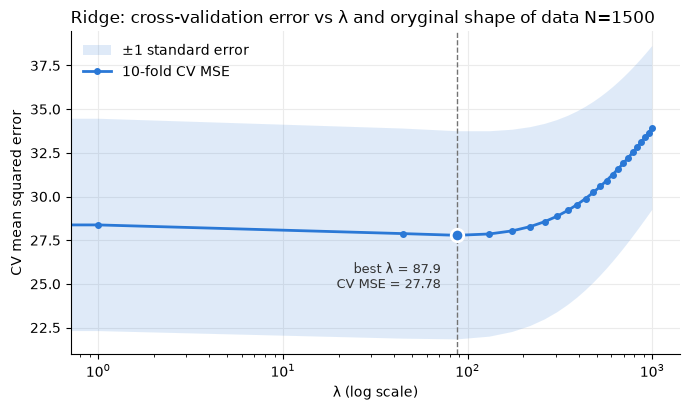

In [17]:
import matplotlib.pyplot as plt

K = square_errors.shape[0]
fold_mse = square_errors / (len(df) / K)               # each fold's MSE (folds are about the same size)
cv_mse = square_errors.sum(axis=0) / len(df)           # CV error for each λ
cv_se = fold_mse.std(axis=0, ddof=1) / np.sqrt(K)      # standard error of the CV error

best_idx = cv_mse.argmin()
best_lambda = lambdas[best_idx]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.fill_between(lambdas, cv_mse - cv_se, cv_mse + cv_se, color="#2a78d6", alpha=0.15, lw=0,
                label="±1 standard error")
ax.plot(lambdas, cv_mse, color="#2a78d6", lw=2, marker="o", ms=4, label="10-fold CV MSE")
ax.axvline(best_lambda, color="0.45", lw=1, ls="--")
ax.plot(best_lambda, cv_mse[best_idx], "o", ms=9, color="#2a78d6", mec="white", mew=2, zorder=3)
ax.annotate(f"best λ = {best_lambda:.3g}\nCV MSE = {cv_mse[best_idx]:.2f}",
            xy=(best_lambda, cv_mse[best_idx]), xytext=(-12, -38), textcoords="offset points",
            ha="right", fontsize=9, color="0.2")

ax.set_xscale("log")
ax.set_xlabel("λ (log scale)")
ax.set_ylabel("CV mean squared error")
ax.set_title("Ridge: cross-validation error vs λ and oryginal shape of data N=1500", loc="left")
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="0.92", lw=0.8); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

$$Ridge:  
i
∑
​
 (y 
i
​
 −β 
0
​
 −x 
i
T
​
 β) 
2
 +λ 
j
∑
​
 β 
j
2
​
$$

((20, 13), (10, 13))

array([ 6,  4,  7,  8, 10,  9,  2,  5,  1,  4,  8,  1,  7,  2,  3,  9, 10,
        6,  3,  5])

In [32]:
#ridge regression similar to the one in the script ex 3.17
Xs_train = X_train.to_numpy()   # standardized with train mean/sd, no intercept
Xs_test  = X_test.to_numpy()

random_gen = np.random.default_rng(13)

#10 folds
N = len(y_train) # size of my train data (20)

#train data has 20 observations (each with 8 predictors plus 1 predicted)
#
#index contains indices to train data, just random values between 0 and 10
index = random_gen.permutation(np.tile(np.arange(0, 10), int(np.ceil(N / 10)))[:N])

# we work without intercept
y_mean = y_train.mean()
yc_train = y_train - y_mean

# define the ridge estimator
def beta_ridge_estimator(X, y, lam):
    return np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ y)

# possible values of lambda (log grid: only 40 obs and 9 predictors)
lambda_seq = np.logspace(-2, 3, 50)
square_errors = np.zeros((10, len(lambda_seq)))
for k in range(0, 10):
    # standardize inside the fold, using only the fold's training part
    
    X_train_k = Xs_train[index != k]
    X_train_mean_k = X_train_k.mean(axis=0)
    X_train_sd_k = X_train_k.std(axis=0, ddof=1)
    X_train_k = (X_train_k - X_train_mean_k) / X_train_sd_k
    X_test_k = (Xs_train[index == k] - X_train_mean_k) / X_train_sd_k
    y_train_k = yc_train[index != k]
    y_train_mean_k = y_train_k.mean()
    y_train_k = y_train_k - y_train_mean_k
    y_test_k = yc_train[index == k] - y_train_mean_k
    for j, lam in enumerate(lambda_seq):
        beta_ridge_k = beta_ridge_estimator(X_train_k, y_train_k, lam)
        square_errors[k - 1, j] = np.sum((y_test_k - X_test_k @ beta_ridge_k) ** 2)

cv_error = square_errors.sum(axis=0)
lambda_min = lambda_seq[np.argmin(cv_error)]
print("ridge lambda (own CV):", round(lambda_min, 3))

# final estimates on the whole training set, intercept = mean of y
beta_ridge = np.concatenate([[y_mean], beta_ridge_estimator(Xs_train, yc_train, lambda_min)])

# errors, same as for LS
mse_train_ridge = np.mean((y_train - Xtr @ beta_ridge) ** 2)
mse_test_ridge  = np.mean((y_test  - Xte @ beta_ridge) ** 2)
print(f"LS    train RMSE {mse_train:.3f}   test MSE {mse_test:.3f}")
print(f"ridge train MSE {mse_train_ridge:.3f}   test MSE {mse_test_ridge:.3f}")

# library check: RidgeCV minimises ||y - Xb||^2 + alpha ||b||^2, same penalty
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
folds = KFold(n_splits=10, shuffle=True, random_state=20200908)
mod_ridge = RidgeCV(alphas=lambda_seq, cv=folds).fit(Xs_train, yc_train)
print("ridge lambda (RidgeCV):", round(mod_ridge.alpha_, 3))

#print(pd.DataFrame({"LS": beta, "ridge": beta_ridge, "RidgeCV": np.r_[y_mean, mod_ridge.coef_]},
#                   index=["intercept"] + PRED).round(3))

ridge lambda (own CV): 2.812
LS    train RMSE 9.711   test MSE 98.317
ridge train MSE 10.706   test MSE 64.552
ridge lambda (RidgeCV): 4.498
